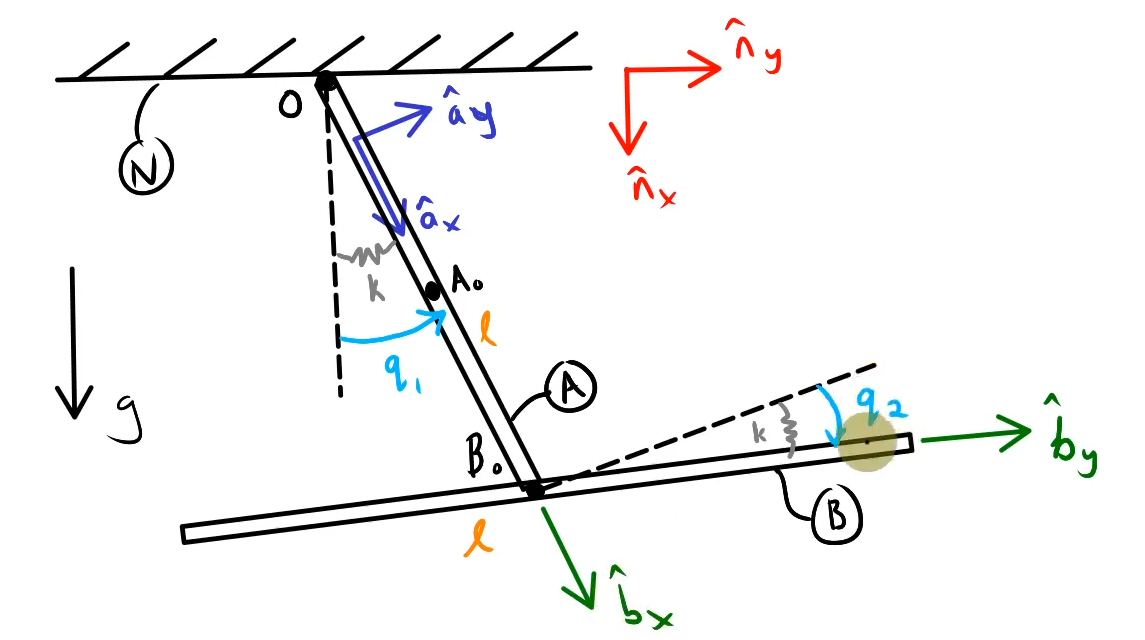

In [63]:
import sympy as sp
import sympy.physics.mechanics as me
me.init_vprinting()


In [64]:
N, A, B = sp.symbols('N A B', cls=me.ReferenceFrame)
O, Ao, Bo = sp.symbols('O A_0 B_0', cls=me.Point)

q1, q2 = me.dynamicsymbols('q1:3')
u1, u2 = me.dynamicsymbols('u1:3')
k, l, m, g = sp.symbols('k l m g', positive="True")

A.orient_axis(N, q1, N.z)
B.orient_axis(A, q2, A.x)

In [65]:
Ao.set_pos(O, l/2*A.x)
Bo.set_pos(Ao, l/2*A.x)

A.set_ang_vel(N, u1*N.z)
B.set_ang_vel(A, u2*A.x)

O.set_vel(N, 0)
Ao.set_vel(A,0)
Bo.set_vel(B,0)

Ao.v2pt_theory(O, N, A)
Bo.v2pt_theory(Ao, N, B)

Ao.vel(N), Bo.vel(N)

### Partial velocities

In [ ]:
### Partial velocities
me.partial_velocity([Ao.vel(N), Bo.vel(N), A.ang_vel_in(N), B.ang_vel_in(N)],
                    [u1, u2],
                    N)

In [67]:
# Partial velocities, the long way

vA_u1 = Ao.vel(N).diff(u1, N) 
vA_u2 = Ao.vel(N).diff(u2, N) 
vB_u1 = Bo.vel(N).diff(u1, N) 
vB_u2 = Bo.vel(N).diff(u2, N) 
wA_u1 = A.ang_vel_in(N).diff(u1, N) 
wA_u2 = A.ang_vel_in(N).diff(u2, N) 
wB_u1 = B.ang_vel_in(N).diff(u1, N) 
wB_u2 = B.ang_vel_in(N).diff(u2, N)

In [68]:
# resultant forces on the points
R_Ao = m*g*N.x
R_Bo = m*g*N.x

# torque on the bodies
T_A = -k*q2*A.x -k*q1*N.z
T_B = -k*q2*A.x

R_Ao, R_Bo, T_A, T_B

## Generalised Active forces

In [ ]:
F_u1 = vA_u1.dot(R_Ao) + vB_u1.dot(R_Bo) + wA_u1.dot(T_A )+ wB_u1.dot(T_B)
F_u2 = vA_u2.dot(R_Ao) + vB_u2.dot(R_Bo) + wA_u2.dot(T_A )+ wB_u2.dot(T_B)

Fr = sp.Matrix([F_u1, F_u2])
Fr

⎡  3⋅g⋅l⋅m⋅sin(q₁)       ⎤
⎢- ─────────────── - k⋅q₁⎥
⎢         2              ⎥
⎢                        ⎥
⎣         -k⋅q₂          ⎦

In [74]:
Ao.acc(N), Bo.acc(N)

In [75]:
A.ang_acc_in(N), B.ang_acc_in(N)

In [79]:
I = m*l**2/12

I_A_Ao = I*me.outer(A.y, A.y) + I*me.outer(A.z, A.z)
I_B_Bo = I*me.outer(B.x, B.x) + I*me.outer(B.z, B.z)

I_A_Ao.to_matrix(A), I_B_Bo.to_matrix(B)

⎛⎡0   0     0  ⎤  ⎡ 2           ⎤⎞
⎜⎢             ⎥  ⎢l ⋅m         ⎥⎟
⎜⎢    2        ⎥  ⎢────  0   0  ⎥⎟
⎜⎢   l ⋅m      ⎥  ⎢ 12          ⎥⎟
⎜⎢0  ────   0  ⎥  ⎢             ⎥⎟
⎜⎢    12       ⎥, ⎢ 0    0   0  ⎥⎟
⎜⎢             ⎥  ⎢             ⎥⎟
⎜⎢          2  ⎥  ⎢          2  ⎥⎟
⎜⎢         l ⋅m⎥  ⎢         l ⋅m⎥⎟
⎜⎢0   0    ────⎥  ⎢ 0    0  ────⎥⎟
⎝⎣          12 ⎦  ⎣          12 ⎦⎠

In [80]:
Rs_Ao = -m*Ao.acc(N)
Rs_Bo = -m*Bo.acc(N)

Rs_Ao, Rs_Bo

In [81]:
Ts_A = -(A.ang_acc_in(N).dot(I_A_Ao) +
         me.cross(A.ang_vel_in(N), I_A_Ao).dot(A.ang_vel_in(N)))

Ts_B = -(B.ang_acc_in(N).dot(I_B_Bo) +
         me.cross(B.ang_vel_in(N), I_B_Bo).dot(B.ang_vel_in(N)))

Ts_A, Ts_B

## Generalised inertia forces

In [83]:
F1s_A = vA_u1.dot(Rs_Ao) + wA_u1.dot(Ts_A)
F1s_B = vB_u1.dot(Rs_Bo) + wB_u1.dot(Ts_B)
F2s_A = vA_u2.dot(Rs_Ao) + wA_u2.dot(Ts_A)
F2s_B = vB_u2.dot(Rs_Bo) + wB_u2.dot(Ts_B)

F1s = F1s_A + F1s_B
F2s = F2s_A + F2s_B

Frs = sp.Matrix([F1s, F2s])
Frs

⎡     2        ⎛   2                                    2                ⎞     ↪
⎢  4⋅l ⋅m⋅u₁̇   ⎜  l ⋅m⋅(-u₁⋅u₂⋅sin(q₂) + cos(q₂)⋅u₁̇)   l ⋅m⋅u₁⋅u₂⋅sin(q₂)⎟     ↪
⎢- ───────── + ⎜- ────────────────────────────────── + ──────────────────⎟⋅cos ↪
⎢      3       ⎝                  12                           12        ⎠     ↪
⎢                                                                              ↪
⎢                         2     2                    2                         ↪
⎢                        l ⋅m⋅u₁ ⋅sin(q₂)⋅cos(q₂)   l ⋅m⋅u₂̇                    ↪
⎢                      - ──────────────────────── - ───────                    ↪
⎣                                   12                12                       ↪

↪     ⎤
↪     ⎥
↪ (q₂)⎥
↪     ⎥
↪     ⎥
↪     ⎥
↪     ⎥
↪     ⎥
↪     ⎦

In [88]:
me.find_dynamicsymbols(Fr)

In [89]:
me.find_dynamicsymbols(Frs)